<a href="https://colab.research.google.com/github/Sisynn/syesildal-cc2526/blob/main/finalassign%C3%BCber80r2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.6/36.6 MB 31.5 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors

def rdkit_descriptors_from_smiles(smiles):
    # convert SMILES string to RDKit molecule
    mol = Chem.MolFromSmiles(smiles)

    # skip molecule if parsing fails
    if mol is None:
        return None

    # calculate basic molecular descriptors
    return {
        "MolWt": Descriptors.MolWt(mol),                     # molecular weight
        "HeavyAtomCount": Descriptors.HeavyAtomCount(mol),   # number of non-hydrogen atoms
        "NumValenceElectrons": Descriptors.NumValenceElectrons(mol),  # total valence electrons
        "NumHDonors": Descriptors.NumHDonors(mol),           # H-bond donors
        "NumHAcceptors": Descriptors.NumHAcceptors(mol),     # H-bond acceptors
        "TPSA": Descriptors.TPSA(mol),                       # polar surface area
        "MolLogP": Descriptors.MolLogP(mol),                 # logP value
        "RingCount": Descriptors.RingCount(mol),             # number of rings
        "NumRotatableBonds": Descriptors.NumRotatableBonds(mol)  # rotatable bonds
    }


In [ ]:
# load QM9 CSV file
df = pd.read_csv("qm9(2).csv")

data = []

# loop over molecules
for _, row in df.iterrows():
    # get RDKit descriptors from SMILES
    desc = rdkit_descriptors_from_smiles(row["smiles"])

    # skip invalid molecules
    if desc is None:
        continue

    # add HOMO-LUMO gap as target value
    desc["gap"] = row["gap"]
    data.append(desc)

# create dataframe for machine learning
df_ml = pd.DataFrame(data)

print("Number of molecules:", len(df_ml))
df_ml.head()


Number of molecules: 23884


,MolWt,HeavyAtomCount,NumValenceElectrons,NumHDonors,NumHAcceptors,TPSA,MolLogP,RingCount,NumRotatableBonds,gap
0,16.043,1,8,0,0,0.00,0.63610,0,0,0.5048
1,17.031,1,8,1,1,35.00,0.16200,0,0,0.3399
2,18.015,1,8,0,0,31.50,-0.82470,0,0,0.3615
3,26.038,2,10,0,0,0.00,0.24940,0,0,0.3351
4,27.026,2,10,0,1,23.79,0.13978,0,0,0.3796


KRR R² score: 0.8223358393783949


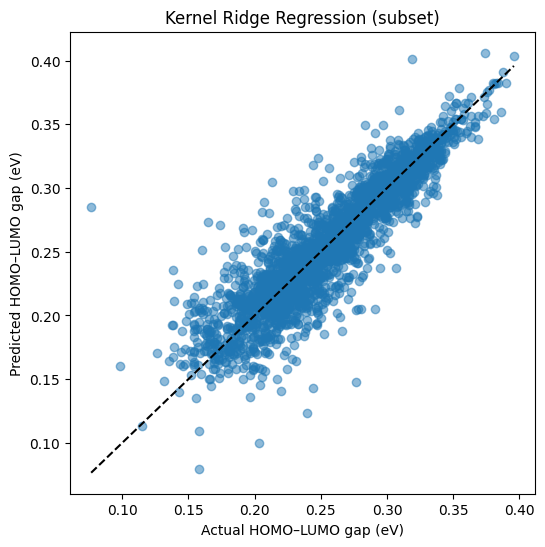

In [60]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.kernel_ridge import KernelRidge
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# Subsample dataset (IMPORTANT for KRR)
df_krr = df_ml.sample(n=15000, random_state=42)

# Features and target
X = df_krr.drop(columns=["gap"]).values
y = df_krr["gap"].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature scaling (mandatory for KRR)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Kernel Ridge Regression model
krr = KernelRidge(
    kernel="laplacian",
    alpha=1e-6,
    gamma=1e-2
)

# Train model
krr.fit(X_train_scaled, y_train)

# Predict
y_pred_krr = krr.predict(X_test_scaled)

# R² score
r2_krr = r2_score(y_test, y_pred_krr)
print("KRR R² score:", r2_krr)

# Parity plot
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_krr, alpha=0.5)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "--", color="black"
)
plt.xlabel("Actual HOMO–LUMO gap (eV)")
plt.ylabel("Predicted HOMO–LUMO gap (eV)")
plt.title("Kernel Ridge Regression (subset)")
plt.show()


Epoch 1/300
338/338 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0069 - val_loss: 0.0015
Epoch 2/300
338/338 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0011 - val_loss: 0.0010
Epoch 3/300
338/338 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 9.8050e-04 - val_loss: 0.0011
Epoch 4/300
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 9.0858e-04 - val_loss: 8.2256e-04
Epoch 5/300
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 7.8420e-04 - val_loss: 8.1174e-04
Epoch 6/300
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 7.1609e-04 - val_loss: 7.3250e-04
Epoch 7/300
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 7.3230e-04 - val_loss: 7.0900e-04
Epoch 8/300
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 6.5646e-04 - val_loss: 6.8648e-04
Epoch 9/300
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5.9901e-04 - val_loss: 6.0845e-04
Epoch 10/300
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.0107e-04 - val_loss: 6.4345e-04
Epoch 11/300
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5.7496e

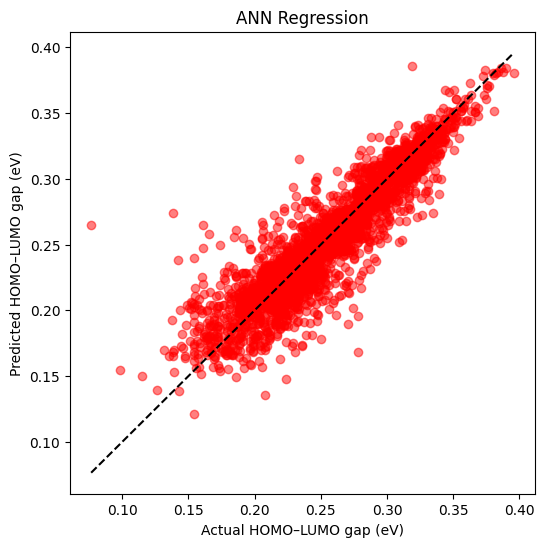

In [30]:
import tensorflow as tf
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# Define simple feed-forward ANN
ann = tf.keras.models.Sequential([
    tf.keras.Input(shape=(X_train_scaled.shape[1],)),  # number of descriptors
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(1)  # output: HOMO-LUMO gap
])

# Compile model (Adam optimizer + MSE loss)
ann.compile(optimizer="adam", loss="mse")

# Train ANN
history = ann.fit(
    X_train_scaled, y_train,
    validation_split=0.1,
    epochs=300,
    batch_size=32,
    verbose=1
)

# Predict on test set
y_pred_ann = ann.predict(X_test_scaled).flatten()

# Compute R² score
r2_ann = r2_score(y_test, y_pred_ann)
print("ANN R² score:", r2_ann)

# Parity plot
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_ann, alpha=0.5, color="red")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], "--", color="black")
plt.xlabel("Actual HOMO–LUMO gap (eV)")
plt.ylabel("Predicted HOMO–LUMO gap (eV)")
plt.title("ANN Regression")
plt.show()


Random Forest R² score: 0.8487077133123381


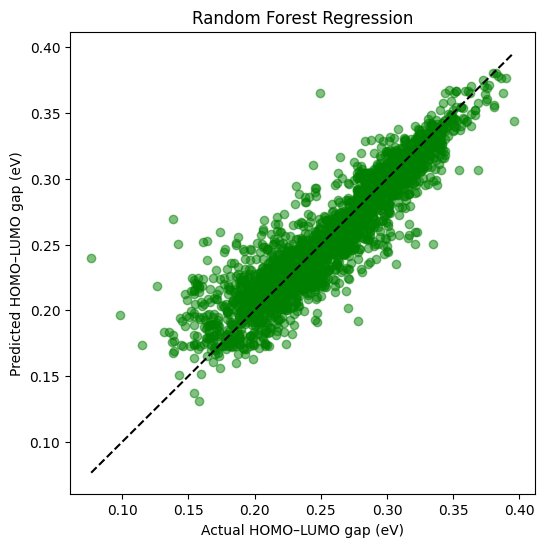

In [59]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# Initialize Random Forest
rf = RandomForestRegressor(n_estimators=700, max_depth=20, min_samples_split=4, min_samples_leaf=1, max_features=1.0, random_state=42, n_jobs=-1)

# Train model
rf.fit(X_train_scaled, y_train)

# Predict on test set
y_pred_rf = rf.predict(X_test_scaled)

# Compute R² score
r2_rf = r2_score(y_test, y_pred_rf)
print("Random Forest R² score:", r2_rf)

# Plot predicted vs actual HOMO-LUMO gaps
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf, alpha=0.5, color="green")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], "--", color="black")
plt.xlabel("Actual HOMO–LUMO gap (eV)")
plt.ylabel("Predicted HOMO–LUMO gap (eV)")
plt.title("Random Forest Regression")
plt.show()
